In [15]:
import pandas as pd

In [16]:
df = pd.read_csv('dataset\data_ready_for_modeling_analist.csv')
df.head()

,reviewId,content,score,at,source,cleaned_content,normalized_text,no_stop_text,tokenized_text,stemmed_tokens,stemmed_text,label,len_words,label_lexicon,label_rating,label_hybrid
0,d84a4955-4bfb-448b-a260-b36935a58c9b,kalo ada pembatalan hub langsung WA dong,1,2026-01-13 12:12:06,tiketcom,kalo ada pembatalan hub langsung wa dong,kalau ada pembatalan hub langsung wa dong,kalau pembatalan hub langsung wa dong,"['kalau', 'pembatalan', 'hub', 'langsung', 'wa...","['kalau', 'batal', 'hub', 'langsung', 'wa', 'd...",kalau batal hub langsung wa dong,negatif,6,negatif,negatif,negatif
1,0b67f755-1fb1-4300-a769-68e45a0a48cc,ganguan terus susah cari jadwal disni,2,2026-01-13 11:18:17,tiketcom,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,ganguan terus susah cari jadwal disni,"['ganguan', 'terus', 'susah', 'cari', 'jadwal'...","['ganguan', 'terus', 'susah', 'cari', 'jadwal'...",ganguan terus susah cari jadwal disni,negatif,6,negatif,negatif,negatif
2,fcef9cb8-5c08-41cf-a8b5-2a2eb1edfba8,banyakin promonya ya,5,2026-01-13 00:01:23,tiketcom,banyakin promonya ya,dibanyaki promonya ya,dibanyaki promonya,"['dibanyaki', 'promonya']","['banyak', 'promonya']",banyak promonya,positif,2,positif,positif,positif
3,d039ee95-c3f2-4e76-ae03-9214f7672cd8,very bad service!!!!!!,1,2026-01-12 21:29:45,tiketcom,very bad service,very bad service,very bad service,"['very', 'bad', 'service']","['very', 'bad', 'service']",very bad service,negatif,3,negatif,negatif,negatif
4,0d830287-f7df-454c-9598-4d6a6071b32a,mantap,5,2026-01-12 13:02:48,tiketcom,mantap,mantap,mantap,['mantap'],['mantap'],mantap,positif,1,positif,positif,positif


In [14]:
df = df[['stemmed_text', 'label', 'label_lexicon']]

df.head()

,stemmed_text,label,label_lexicon
0,kalau batal hub langsung wa dong,negatif,negatif
1,ganguan terus susah cari jadwal disni,negatif,negatif
2,banyak promonya,positif,positif
3,very bad service,negatif,negatif
4,mantap,positif,positif


RINGKASAN PERBANDINGAN (LinearSVC + TF-IDF)
                 label_source  accuracy  f1_macro
Label Lexicon (label_lexicon)  0.922214  0.879688
         Label Rating (label)  0.908900  0.607937

CLASSIFICATION REPORT - LABEL RATING
              precision    recall  f1-score   support

     negatif     0.8079    0.8494    0.8281       312
      netral     0.2500    0.0250    0.0455        40
     positif     0.9416    0.9591    0.9502      1075

    accuracy                         0.9089      1427
   macro avg     0.6665    0.6111    0.6079      1427
weighted avg     0.8930    0.9089    0.8982      1427


CLASSIFICATION REPORT - LABEL LEXICON
              precision    recall  f1-score   support

     negatif     0.8241    0.7841    0.8036       227
      netral     0.8320    0.9227    0.8750       220
     positif     0.9669    0.9541    0.9605       980

    accuracy                         0.9222      1427
   macro avg     0.8743    0.8870    0.8797      1427
weighted avg     0.923

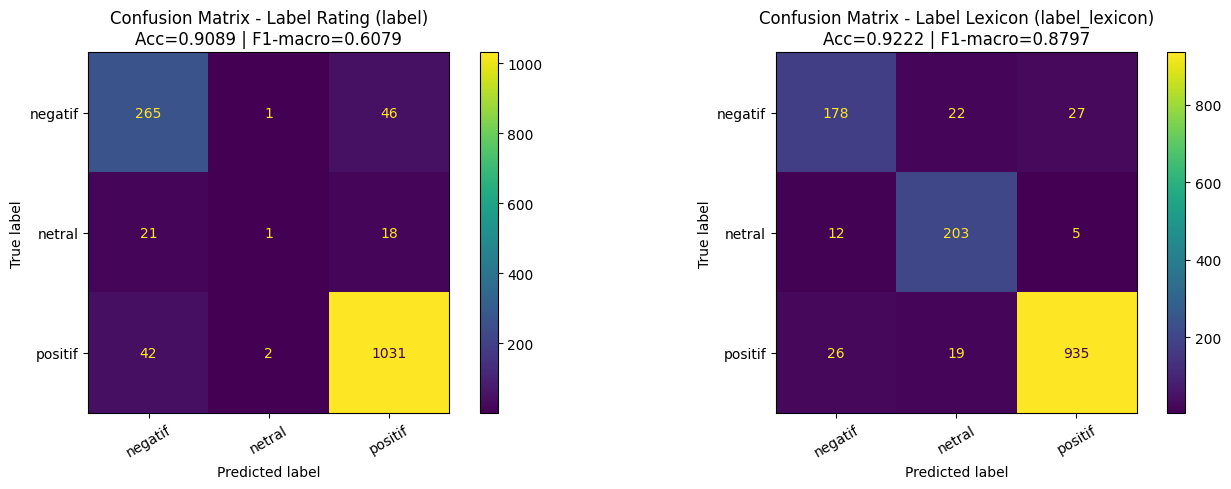

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score, f1_score,
    ConfusionMatrixDisplay, classification_report
)

# =========================
# DATA
# =========================
TEXT_COL = "stemmed_text"
LABEL_RATING_COL = "label"          # label dari rating
LABEL_LEX_COL    = "label_lexicon"  # label dari lexicon

# bersihin minimal: teks + label tidak boleh kosong
df_model = df[[TEXT_COL, LABEL_RATING_COL, LABEL_LEX_COL]].copy()
df_model[TEXT_COL] = df_model[TEXT_COL].fillna("").astype(str).str.strip()

for c in [LABEL_RATING_COL, LABEL_LEX_COL]:
    df_model[c] = df_model[c].astype(str).str.strip().str.lower()
    df_model.loc[df_model[c].isin(["", "nan", "none"]), c] = np.nan

df_model = df_model.dropna(subset=[TEXT_COL, LABEL_RATING_COL, LABEL_LEX_COL])

X = df_model[TEXT_COL]

# urutan label konsisten
LABEL_ORDER = ["negatif", "netral", "positif"]

# =========================
# MODEL PIPELINE
# =========================
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(random_state=42))
])

def run_experiment(y_col, title):
    y = df_model[y_col]

    # pastikan stratify aman (setiap kelas minimal 2 data utk split)
    vc = y.value_counts()
    too_small = vc[vc < 2].index.tolist()
    if too_small:
        # drop kelas yang terlalu sedikit agar train_test_split tidak error
        keep_mask = ~y.isin(too_small)
        X_use = X[keep_mask]
        y_use = y[keep_mask]
    else:
        X_use, y_use = X, y

    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use,
        test_size=0.2,
        random_state=42,
        stratify=y_use
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")

    # label yang benar-benar muncul di data split
    labels_present = [lab for lab in LABEL_ORDER if lab in set(y_use)]

    report = classification_report(
        y_test, pred,
        labels=labels_present,
        digits=4,
        zero_division=0
    )

    return {
        "title": title,
        "y_col": y_col,
        "accuracy": acc,
        "f1_macro": f1m,
        "y_test": y_test,
        "pred": pred,
        "labels": labels_present,
        "report": report
    }

# =========================
# 2 EKSPERIMEN (sesuai kolom datasetmu)
# =========================
exp_rating = run_experiment(LABEL_RATING_COL, "Label Rating (label)")
exp_lex    = run_experiment(LABEL_LEX_COL,    "Label Lexicon (label_lexicon)")

# =========================
# RINGKASAN HASIL
# =========================
results_df = pd.DataFrame([
    {"label_source": exp_rating["title"], "accuracy": exp_rating["accuracy"], "f1_macro": exp_rating["f1_macro"]},
    {"label_source": exp_lex["title"],    "accuracy": exp_lex["accuracy"],    "f1_macro": exp_lex["f1_macro"]},
]).sort_values("f1_macro", ascending=False)

print("RINGKASAN PERBANDINGAN (LinearSVC + TF-IDF)")
print(results_df.to_string(index=False))

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n" + "="*70)
print("CLASSIFICATION REPORT - LABEL RATING")
print("="*70)
print(exp_rating["report"])

print("\n" + "="*70)
print("CLASSIFICATION REPORT - LABEL LEXICON")
print("="*70)
print(exp_lex["report"])

# =========================
# CONFUSION MATRIX
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    exp_rating["y_test"], exp_rating["pred"],
    labels=exp_rating["labels"],
    xticks_rotation=30,
    values_format="d",
    ax=axes[0]
)
axes[0].set_title(
    f"Confusion Matrix - {exp_rating['title']}\n"
    f"Acc={exp_rating['accuracy']:.4f} | F1-macro={exp_rating['f1_macro']:.4f}"
)

ConfusionMatrixDisplay.from_predictions(
    exp_lex["y_test"], exp_lex["pred"],
    labels=exp_lex["labels"],
    xticks_rotation=30,
    values_format="d",
    ax=axes[1]
)
axes[1].set_title(
    f"Confusion Matrix - {exp_lex['title']}\n"
    f"Acc={exp_lex['accuracy']:.4f} | F1-macro={exp_lex['f1_macro']:.4f}"
)

plt.tight_layout()
plt.show()



══════════════════════════════════════════════════════════════════════════════
                    CLASSIFICATION REPORT • LABEL LEXICON                     
══════════════════════════════════════════════════════════════════════════════
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ class        │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ negatif      │      0.8241 │   0.7841 │     0.8036 │       227 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ netral       │      0.832  │   0.9227 │     0.875  │       220 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ positif      │      0.9669 │   0.9541 │     0.9605 │       980 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │      0.9222 │   0.9222 │     0.9222 │         0 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │      0.8

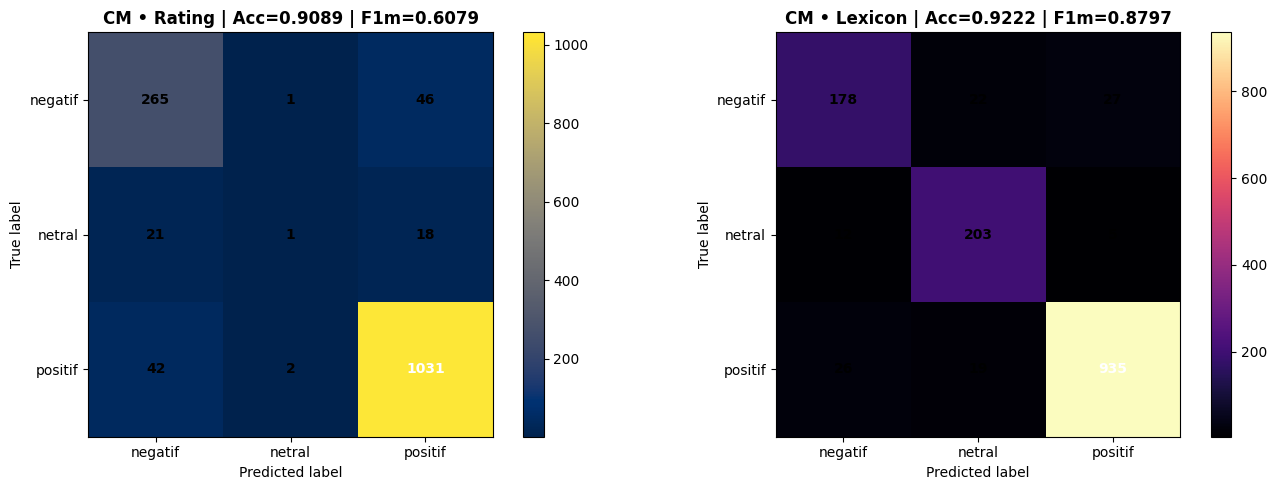

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score,
    ConfusionMatrixDisplay, classification_report
)

# pip install tabulate colorama (opsional, tapi bikin CLI lebih enak)
try:
    from tabulate import tabulate
except Exception:
    tabulate = None

# =========================
# 1) CLI OUTPUT: tabel rapi
# =========================
def pretty_report(y_true, y_pred, title, labels=None):
    """
    Print classification report dalam format tabel (lebih rapi dari default sklearn).
    """
    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )
    df_rep = pd.DataFrame(rep).T

    # rapikan urutan baris
    preferred = []
    if labels is not None:
        preferred += list(labels)
    preferred += ["accuracy", "macro avg", "weighted avg"]
    idx = [i for i in preferred if i in df_rep.index]
    df_rep = df_rep.loc[idx]

    # pembulatan
    for c in ["precision", "recall", "f1-score"]:
        if c in df_rep.columns:
            df_rep[c] = df_rep[c].astype(float).round(4)
    if "support" in df_rep.columns:
        df_rep["support"] = df_rep["support"].fillna(0).astype(int)

    print("\n" + "═"*78)
    print(f"{title}".center(78))
    print("═"*78)

    if tabulate:
        print(tabulate(df_rep.reset_index().rename(columns={"index":"class"}),
                       headers="keys", tablefmt="fancy_grid", showindex=False))
    else:
        # fallback tanpa tabulate
        print(df_rep.to_string())

    # ringkas metrik utama
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"\nAcc: {acc:.4f} | F1-macro: {f1m:.4f}")

# =========================
# 2) CONFUSION MATRIX: gaya & warna beda
# =========================
def plot_cm(y_true, y_pred, title, labels, ax, cmap="cividis"):
    """
    Confusion matrix dengan colormap berbeda + angka kontras.
    """
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        labels=labels,
        values_format="d",
        xticks_rotation=0,
        cmap=cmap,
        ax=ax
    )
    ax.set_title(title, fontweight="bold")

    # bikin angka lebih kebaca (kontras otomatis)
    im = ax.images[0]
    data = im.get_array().data
    thresh = (data.max() + data.min()) / 2.0
    for t in disp.text_.ravel():
        try:
            val = float(t.get_text())
            t.set_color("white" if val > thresh else "black")
            t.set_fontweight("bold")
        except:
            pass

    ax.grid(False)

# =========================
# CONTOH PEMAKAIAN DENGAN HASIL EXP KAMU
# exp_rating = {...} dan exp_lex = {...} dari fungsi run_experiment kamu
# =========================

# --- CLI (tabel) ---

pretty_report(
    exp_lex["y_test"], exp_lex["pred"],
    title="CLASSIFICATION REPORT • LABEL LEXICON",
    labels=exp_lex["labels"]
)

# --- Confusion Matrix (warna beda + layout beda) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cm(
    exp_rating["y_test"], exp_rating["pred"],
    title=f"CM • Rating | Acc={exp_rating['accuracy']:.4f} | F1m={exp_rating['f1_macro']:.4f}",
    labels=exp_rating["labels"],
    ax=axes[0],
    cmap="cividis"   # beda dari yang umum
)

plot_cm(
    exp_lex["y_test"], exp_lex["pred"],
    title=f"CM • Lexicon | Acc={exp_lex['accuracy']:.4f} | F1m={exp_lex['f1_macro']:.4f}",
    labels=exp_lex["labels"],
    ax=axes[1],
    cmap="magma"     # beda lagi biar jelas
)

plt.tight_layout()
plt.show()


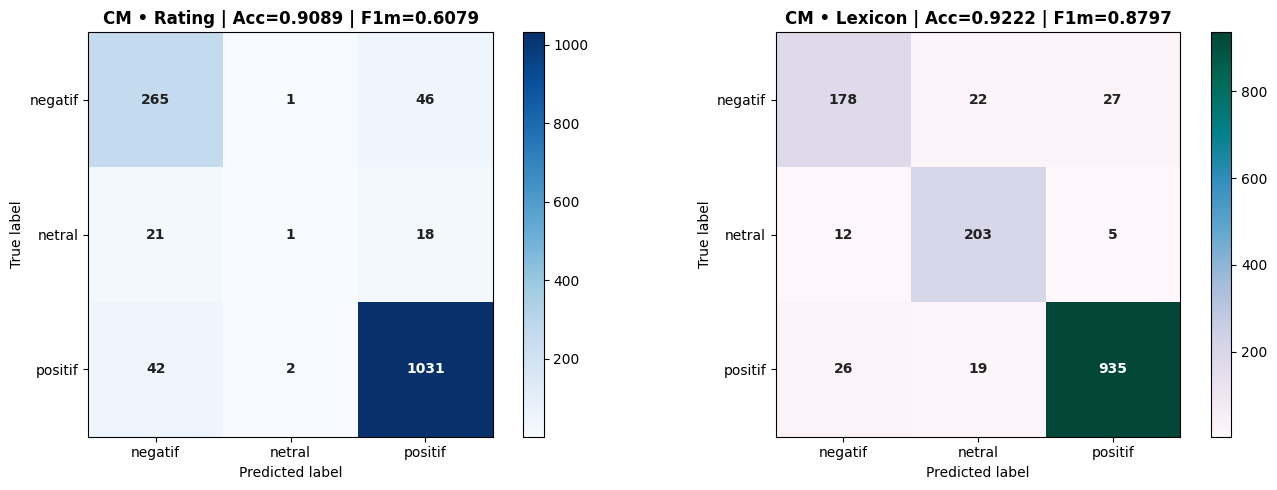

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm_soft(y_true, y_pred, title, labels, ax, cmap="Blues"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        labels=labels,
        values_format="d",
        xticks_rotation=0,
        cmap=cmap,
        ax=ax,
        colorbar=True
    )
    ax.set_title(title, fontweight="bold")

    # angka kontras otomatis (biar tetap kebaca)
    im = ax.images[0]
    data = im.get_array().data
    thresh = (data.max() + data.min()) / 2.0

    for t in disp.text_.ravel():
        try:
            val = float(t.get_text())
            t.set_color("white" if val > thresh else "#222222")
            t.set_fontweight("bold")
        except:
            pass

    ax.grid(False)

# ====== PEMAKAIAN ======
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cm_soft(
    exp_rating["y_test"], exp_rating["pred"],
    title=f"CM • Rating | Acc={exp_rating['accuracy']:.4f} | F1m={exp_rating['f1_macro']:.4f}",
    labels=exp_rating["labels"],
    ax=axes[0],
    cmap="Blues"      # nyaman & umum dipakai
)

plot_cm_soft(
    exp_lex["y_test"], exp_lex["pred"],
    title=f"CM • Lexicon | Acc={exp_lex['accuracy']:.4f} | F1m={exp_lex['f1_macro']:.4f}",
    labels=exp_lex["labels"],
    ax=axes[1],
    cmap="PuBuGn"     # beda tapi tetap kalem
)

plt.tight_layout()
plt.show()
